# Generative AI
## Practical 2
---
### Build a text classification model for a binary or multi classclassification task using an Embedding layer and an LSTM network. Evaluate the model performance using appropriate classification metrics.
---
**Name:** Gandhar Sunil Chafle\
**PRN:** 202401110018\
**Batch:** A2




In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(
    num_words=10000
)
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [ ]:
for i in range(10):
  print("First encoded review:")
  print(x_train[i])

  print("\nFirst review's label:")
  print(y_train[i])

  print("\nLength of first review:")
  print(len(x_train[i]))

First encoded review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First review's label:
1

Length of fi

#Decoding

In [ ]:
word_index = tf.keras.datasets.imdb.get_word_index()
print("Number of words in vocabulary:", len(word_index))
for word, index in list(word_index.items())[:20]:
    print(word, "->", index)

Number of words in vocabulary: 88584
fawn -> 34701
tsukino -> 52006
nunnery -> 52007
sonja -> 16816
vani -> 63951
woods -> 1408
spiders -> 16115
hanging -> 2345
woody -> 2289
trawling -> 52008
hold's -> 52009
comically -> 11307
localized -> 40830
disobeying -> 30568
'royale -> 52010
harpo's -> 40831
canet -> 52011
aileen -> 19313
acurately -> 52012
diplomat's -> 52013


In [ ]:
index_word = {index + 3: word for word, index in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"

print("Example mappings:")

for index in range(30):
    print(index, "->", index_word.get(index, "<UNKNOWN>"))

Example mappings:
0 -> <PAD>
1 -> <START>
2 -> <UNK>
3 -> <UNKNOWN>
4 -> the
5 -> and
6 -> a
7 -> of
8 -> to
9 -> is
10 -> br
11 -> in
12 -> it
13 -> i
14 -> this
15 -> that
16 -> was
17 -> as
18 -> for
19 -> with
20 -> movie
21 -> but
22 -> film
23 -> on
24 -> not
25 -> you
26 -> are
27 -> his
28 -> have
29 -> he


In [ ]:
for i in range(5):
    decoded_review = " ".join(index_word.get(j, "<UNKNOWN>") for j in x_train[i])

    sentiment = "Positive" if y_train[i] == 1 else "Negative"

    print(f"\nReview {i + 1}")
    print("Sentiment:", sentiment)
    print("Review:", decoded_review)


Review 1
Sentiment: Positive
Review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are

In [ ]:
train_lengths = [len(review) for review in x_train]

print("Minimum review length:", min(train_lengths))
print("Maximum review length:", max(train_lengths))
print("Average review length:", np.mean(train_lengths))

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364


In [ ]:
MAX_LEN = 200

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_padded = pad_sequences(
    x_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_test_padded = pad_sequences(
    x_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Padded training shape:", x_train_padded.shape)
print("Padded testing shape:", x_test_padded.shape)

Padded training shape: (25000, 200)
Padded testing shape: (25000, 200)


In [ ]:
original_length = len(x_train[0])

print("Original length:", original_length)
print("Padded length:", len(x_train_padded[0]))

print("\nOriginal sequence:")
print(x_train[0])

print("\nPadded sequence:")
print(x_train_padded[0])

Original length: 218
Padded length: 200

Original sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [ ]:
print("First 10 training labels:")
print(y_train[:10])

print("\nUnique labels:")
print(np.unique(y_train))

First 10 training labels:
[1 0 0 1 0 0 1 0 1 0]

Unique labels:
[0 1]


#Compiling


In [ ]:
VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
LSTM_UNITS = 64

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    tf.keras.layers.LSTM(LSTM_UNITS),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

print("Model created successfully!")

Model created successfully!


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


#Training

In [ ]:
EPOCHS = 6
BATCH_SIZE = 64

history = model.fit(
    x_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5248 - loss: 0.6894 - val_accuracy: 0.6332 - val_loss: 0.6573
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6349 - loss: 0.6378 - val_accuracy: 0.7236 - val_loss: 0.5877
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7273 - loss: 0.5602 - val_accuracy: 0.7668 - val_loss: 0.5534
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7408 - loss: 0.5306 - val_accuracy: 0.5662 - val_loss: 0.6788
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7462 - loss: 0.4958 - val_accuracy: 0.7934 - val_loss: 0.4794
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8907 - loss: 0.2754 - val_accuracy: 0.8524 - val_loss: 0.3834


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]

final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print(f"Final Training Accuracy:   {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

print(f"Final Training Loss:        {final_train_loss:.4f}")
print(f"Final Validation Loss:      {final_val_loss:.4f}")

Final Training Accuracy:   0.8907
Final Validation Accuracy: 0.8524
Final Training Loss:        0.2754
Final Validation Loss:      0.3834


#Visualization

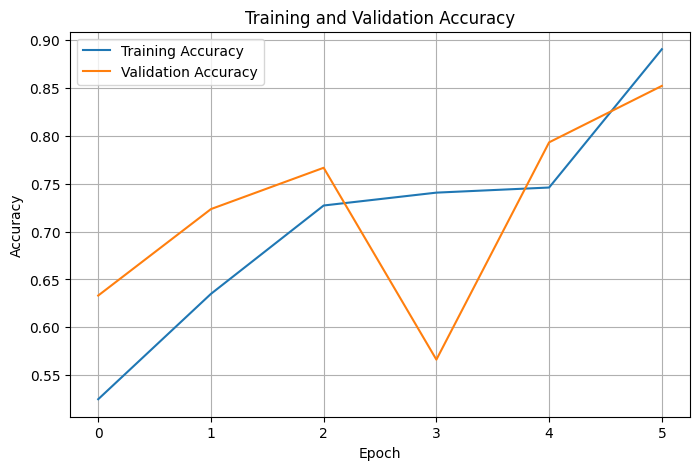

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

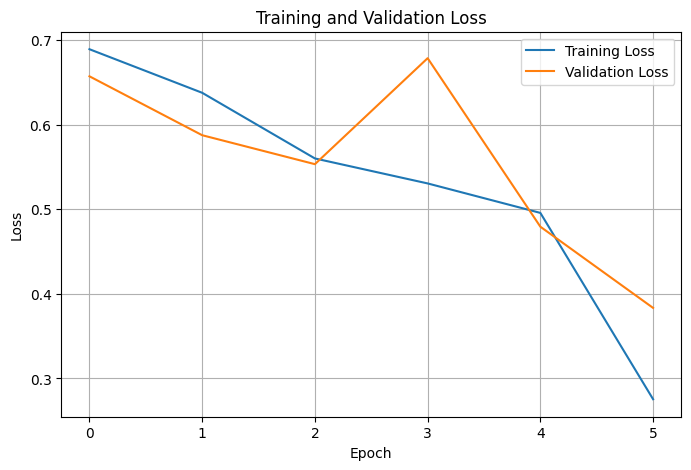

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
results = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

print(results.to_string(index=False))

 Epoch  Training Accuracy  Validation Accuracy  Training Loss  Validation Loss
     1            0.52480               0.6332       0.689371         0.657335
     2            0.63495               0.7236       0.637833         0.587656
     3            0.72735               0.7668       0.560186         0.553410
     4            0.74080               0.5662       0.530634         0.678756
     5            0.74615               0.7934       0.495763         0.479446
     6            0.89075               0.8524       0.275402         0.383402


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test_padded,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8331 - loss: 0.4198

Test Loss: 0.4198
Test Accuracy: 0.8331


In [ ]:
y_pred_probability = model.predict(
    x_test_padded,
    verbose=1
)

print("Prediction shape:", y_pred_probability.shape)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Prediction shape: (25000, 1)


In [ ]:
y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

print("First 20 predicted labels:")
print(y_pred[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])

First 20 predicted labels:
[0 1 1 0 1 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0]

First 20 actual labels:
[0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]


In [ ]:
for i in range(10):
    review = " ".join(index_word.get(j, "<UNKNOWN>") for j in x_test[i])

    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if y_pred[i] == 1 else "Negative"

    print(f"\nReview {i + 1}")
    print("Review:", review[:300], "...")
    print("Actual:", actual)
    print("Predicted:", predicted)


Review 1
Review: <START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quit ...
Actual: Negative
Predicted: Negative

Review 2
Review: <START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances <UNK> the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an  ...
Actual: Positive
Predicted: Positive

Review 3
Review: <START> many animation buffs consider <UNK> <UNK> the great forgotten genius of one special branch of the art puppet animation which he invented almost single <UNK> and as it happened almost accidentally as a young man <UNK> was more interested in <UNK> than the

#Evaluation



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")

Accuracy : 83.31%
Precision: 83.07%
Recall   : 83.67%
F1-Score : 83.37%


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10369  2131]
 [ 2041 10459]]


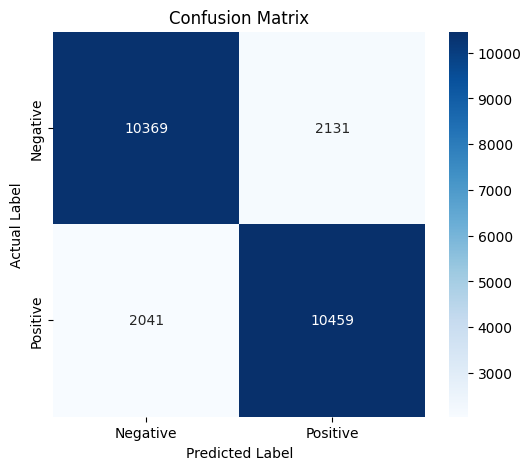

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df["Percentage"] = metrics_df["Score"] * 100

print(metrics_df.to_string(index=False))

   Metric    Score  Percentage
 Accuracy 0.833120   83.312000
Precision 0.830739   83.073868
   Recall 0.836720   83.672000
 F1-Score 0.833719   83.371861
